In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler


# **DATASET**

In [78]:
df = pd.read_csv('../../data/pima-indians-diabetes.csv')
df.head()

,6,148,72,35,0,33.6,0.627,50,1
0,1,85,66,29,0,26.6,0.351,31,0
1,8,183,64,0,0,23.3,0.672,32,1
2,1,89,66,23,94,28.1,0.167,21,0
3,0,137,40,35,168,43.1,2.288,33,1
4,5,116,74,0,0,25.6,0.201,30,0


# **PHÂN TÍCH DỮ LIỆU (EDA)**

## Tổng quan dữ liệu

In [79]:
row, column = df.shape
print(f"Row: {row}, Column: {column}")


Row: 767, Column: 9


In [80]:
# Gán lại tên cột chuẩn
df.columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

In [81]:
# Thông tin kiểu dữ liệu, null
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 767 entries, 0 to 766
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               767 non-null    int64  
 1   Glucose                   767 non-null    int64  
 2   BloodPressure             767 non-null    int64  
 3   SkinThickness             767 non-null    int64  
 4   Insulin                   767 non-null    int64  
 5   BMI                       767 non-null    float64
 6   DiabetesPedigreeFunction  767 non-null    float64
 7   Age                       767 non-null    int64  
 8   Outcome                   767 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [82]:
# Kiểm tra giá trị thiếu (null)
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [83]:
# Thống kê cơ bản các cột số
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,767.000000,767.000000,767.000000,767.000000,767.000000,767.000000,767.000000,767.000000,767.000000
mean,3.842243,120.859192,69.101695,20.517601,79.903520,31.990482,0.471674,33.219035,0.348110
std,3.370877,31.978468,19.368155,15.954059,115.283105,7.889091,0.331497,11.752296,0.476682
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243500,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,32.000000,32.000000,0.371000,29.000000,0.000000
75%,6.000000,140.000000,80.000000,32.000000,127.500000,36.600000,0.625000,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [84]:
# Kiểm tra dữ liệu có trùng lặp
df.duplicated().any()

np.False_

**Nhân xét:**

*   Kích thước dữ liệu là (767, 9).



*   Không có cột thiếu dữ liệu

*   Outcome là nhãn của dữ liệu.

*   Các cột có sự phân tán cao là: Insulin, Glucose, Age.
*   Các cột có sự phân tán trung bình là: BMI, BloodPressure.
*   Các cột có sự phân tán thấp là: Pregnancies, SkinThickness, DiabetesPedigreeFunction.

*   Dữ liệu không có sự trùng lặp.


## PHÂN TÍCH ĐƠN BIẾN

### Pregnancies

Text(0, 0.5, 'Frequency')

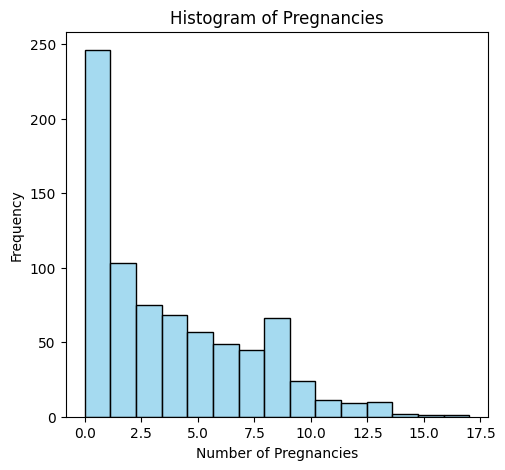

In [85]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df["Pregnancies"], bins=15, kde=False, color="skyblue")
plt.title("Histogram of Pregnancies")
plt.xlabel("Number of Pregnancies")
plt.ylabel("Frequency")

Text(0, 0.5, ' Pregnancies')

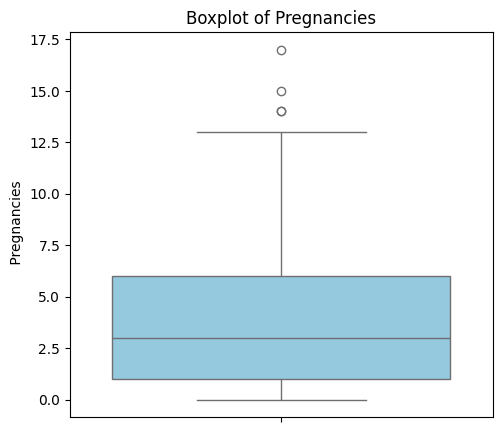

In [86]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,2)
sns.boxplot(df["Pregnancies"], color="skyblue")
plt.title("Boxplot of Pregnancies")
plt.ylabel(" Pregnancies")

# plt.tight_layout()


***Nhận Xét***
- Dữ liệu phân tán không đều lệch phải, tức phần lớn giá trị gần 0 xuất hiện thường xuyên hơn
- Càng về bên trái (giá trị lớn) tần suất càng giảm.
- Trung vị nẳm ở khoảng 3 cho thấy dữ liệu đa phần tập trung ở đây 
- Ít giá trị ngoại lai

### Glucose

Text(0, 0.5, 'Frequency')

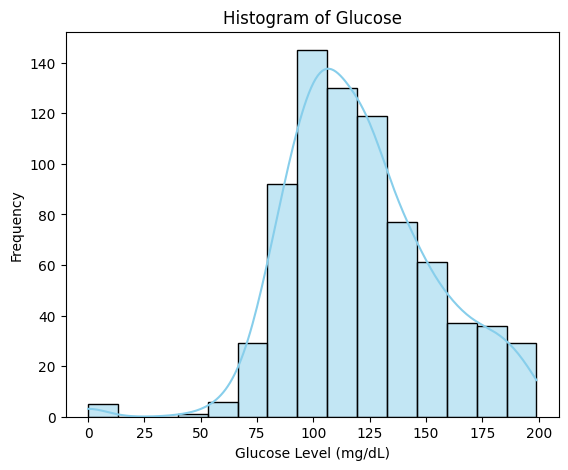

In [87]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
sns.histplot(df["Glucose"], bins=15, kde=True, color="skyblue")
plt.title("Histogram of Glucose")
plt.xlabel("Glucose Level (mg/dL)")
plt.ylabel("Frequency")

Text(0, 0.5, ' Glucose')

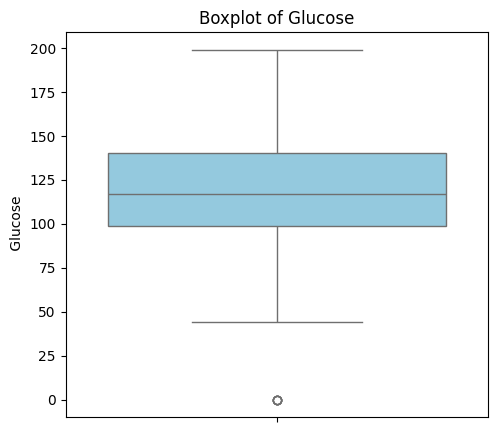

In [88]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,2)
sns.boxplot(df["Glucose"], color="skyblue")
plt.title("Boxplot of Glucose")
plt.ylabel(" Glucose")

# plt.tight_layout()


***Nhận Xét***
- Phân phối của Glucose khá đa dạng nhưn lệch nhiều về bến trái
- Median (giá trị trung vị) nằm khoảng 110–120, là mức giá phổ biến nhất.

### BloodPressure

Text(0, 0.5, 'Frequency')

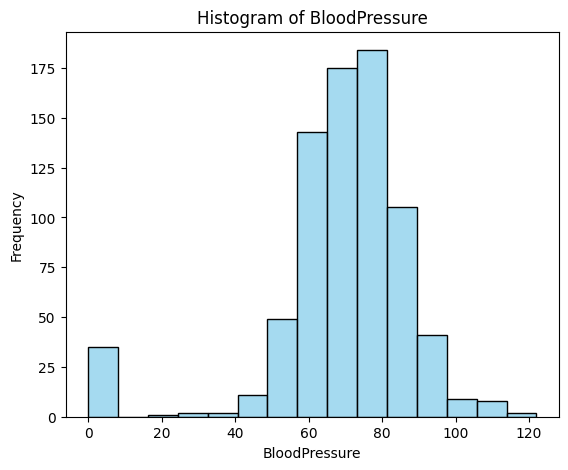

In [89]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
sns.histplot(df["BloodPressure"], bins=15, kde=False, color="skyblue")
plt.title("Histogram of BloodPressure")
plt.xlabel("BloodPressure")
plt.ylabel("Frequency")

Text(0, 0.5, ' BloodPressure')

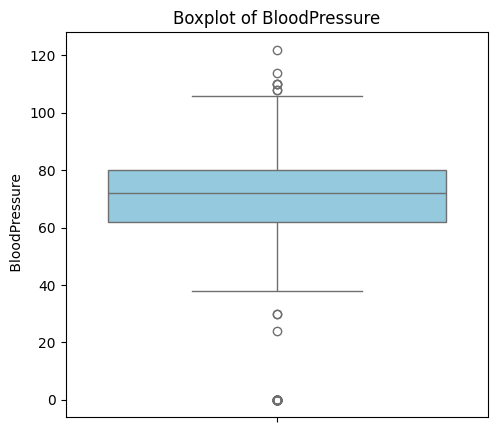

In [90]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,2)
sns.boxplot(df["BloodPressure"], color="skyblue")
plt.title("Boxplot of BloodPressure")
plt.ylabel(" BloodPressure")

# plt.tight_layout()


***Nhận Xét***
- Dữ liệu phân tán không đều lệch trái , nhưng không bị lẹch hoàn toàn về bến trái
- Median (giá trị trung vị) nằm khoảng 72, có một vài giá trị ngoại lai


### SkinThickness

Text(0, 0.5, 'Frequency')

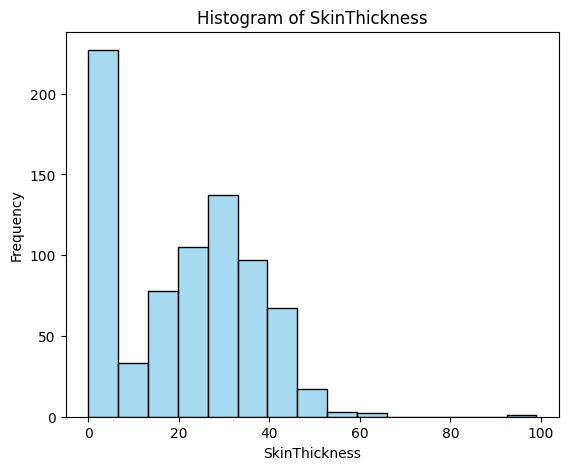

In [91]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
sns.histplot(df["SkinThickness"], bins=15, kde=False, color="skyblue")
plt.title("Histogram of SkinThickness")
plt.xlabel("SkinThickness")
plt.ylabel("Frequency")

Text(0, 0.5, ' SkinThickness')

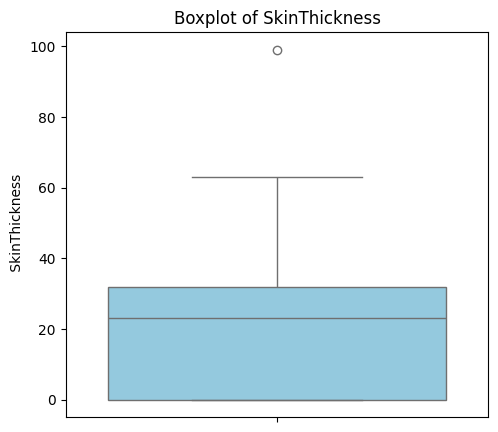

In [92]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,2)
sns.boxplot(df["SkinThickness"], color="skyblue")
plt.title("Boxplot of SkinThickness")
plt.ylabel(" SkinThickness")

# plt.tight_layout()


***Nhận Xét***
- Dữ liệu phân tán đa dạng nhưng không đều lệch phải, tức phần lớn giá trị gần 0 xuất hiện thường xuyên hơn
- Càng về bên trái (giá trị lớn) tần suất càng giảm.


### Insulin

Text(0, 0.5, 'Frequency')

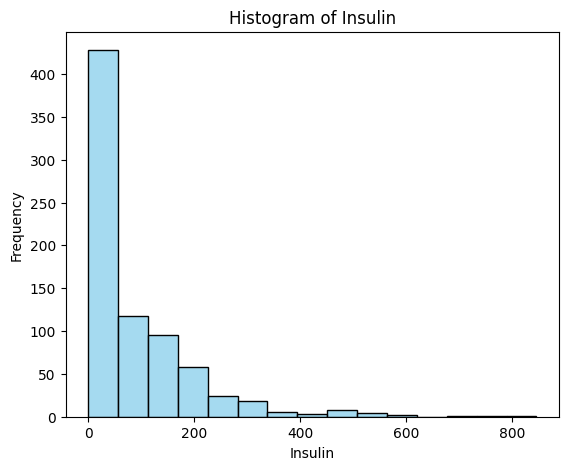

In [93]:
plt.figure(figsize= (14,5))
plt.subplot(1,2,1)
sns.histplot(df["Insulin"], bins=15, kde=False, color="skyblue")
plt.title("Histogram of Insulin")
plt.xlabel("Insulin")
plt.ylabel("Frequency")


Text(0, 0.5, ' Insulin')

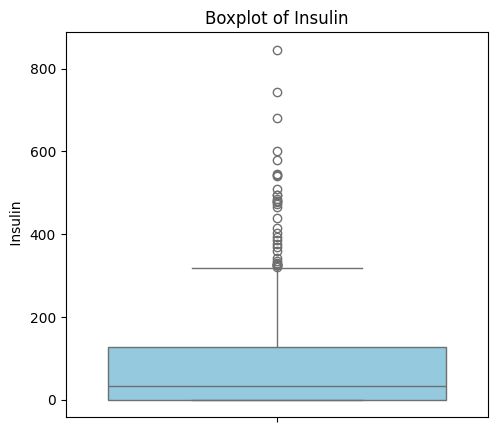

In [94]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,2)
sns.boxplot(df["Insulin"], color="skyblue")
plt.title("Boxplot of Insulin")
plt.ylabel(" Insulin")

# plt.tight_layout()


***Nhận Xét***
- Dữ liệu phân tán không đều lệch phải, tức phần lớn giá trị gần 0 xuất hiện thường xuyên hơn
- Càng về bên trái (giá trị lớn) tần suất càng giảm.
- Trung vị nẳm ở khoảng 70-80 cho thấy dữ liệu đa phần tập trung ở đây 
- Khá nhiều giá trị ngoại lai

### BMI

Text(0, 0.5, 'Frequency')

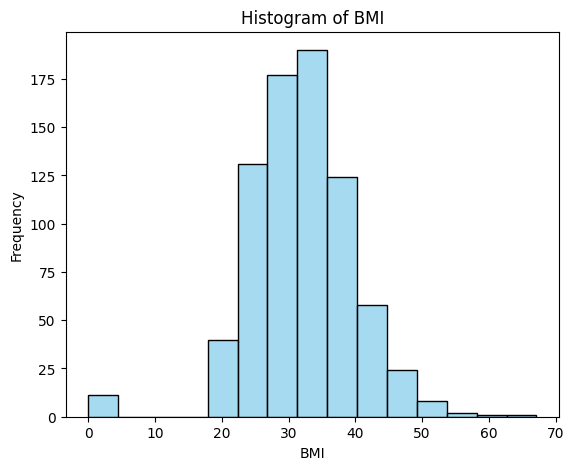

In [95]:
plt.figure(figsize= (14,5))
plt.subplot(1,2,1)
sns.histplot(df["BMI"], bins=15, kde=False, color="skyblue")
plt.title("Histogram of BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")


Text(0, 0.5, ' BMI')

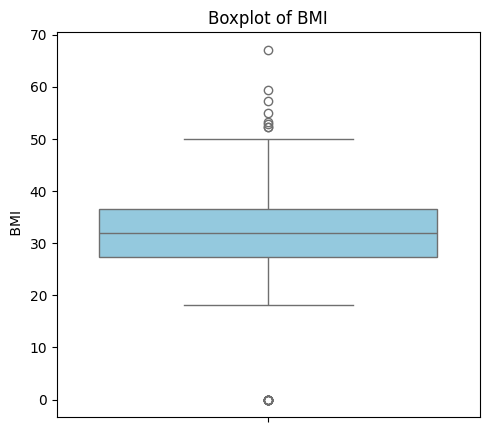

In [96]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,2)
sns.boxplot(df["BMI"], color="skyblue")
plt.title("Boxplot of BMI")
plt.ylabel(" BMI")

# plt.tight_layout()


***Nhận Xét***
- Phân bố đa dạng nhưng không đồng đều.
- Median (giá trị trung vị) nằm khoảng 32, phần lớn dữ liệu tập chung ở đây


### DiabetesPedigreeFunction

Text(0, 0.5, 'Frequency')

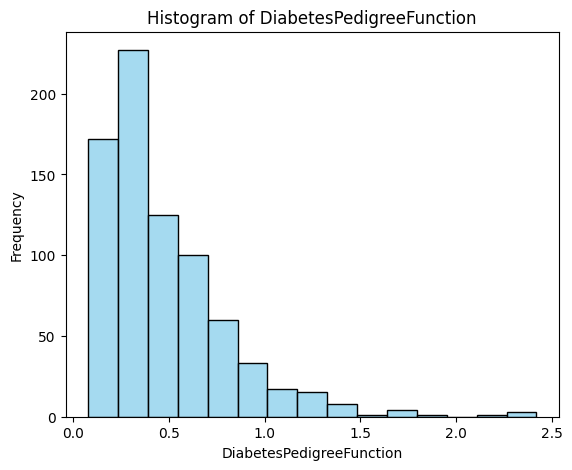

In [97]:
plt.figure(figsize= (14,5))
plt.subplot(1,2,1)
sns.histplot(df["DiabetesPedigreeFunction"], bins=15, kde=False, color="skyblue")
plt.title("Histogram of DiabetesPedigreeFunction")
plt.xlabel("DiabetesPedigreeFunction")
plt.ylabel("Frequency")


Text(0, 0.5, ' DiabetesPedigreeFunction')

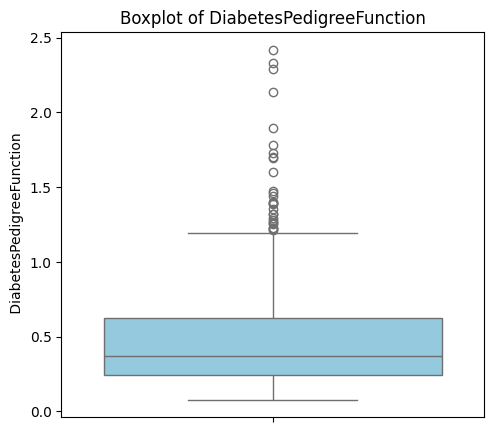

In [98]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,2)
sns.boxplot(df["DiabetesPedigreeFunction"], color="skyblue")
plt.title("Boxplot of DiabetesPedigreeFunction")
plt.ylabel(" DiabetesPedigreeFunction")

# plt.tight_layout()


***Nhận Xét***

- Dữ liệu phân tán không đều lệch phải, tức phần lớn giá trị gần 0 xuất hiện thường xuyên hơn
- Càng về bên trái (giá trị lớn) tần suất càng giảm.
- Trung vị nẳm ở khoảng 0.3 cho thấy dữ liệu đa phần tập trung ở đây 
- Khá nhiều giá trị ngoại lai

### Age

Text(0, 0.5, 'Frequency')

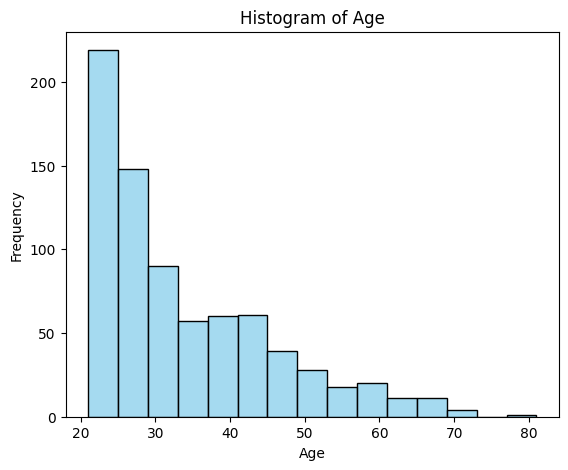

In [99]:
plt.figure(figsize= (14,5))
plt.subplot(1,2,1)
sns.histplot(df["Age"], bins=15, kde=False, color="skyblue")
plt.title("Histogram of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")


Text(0, 0.5, ' Age')

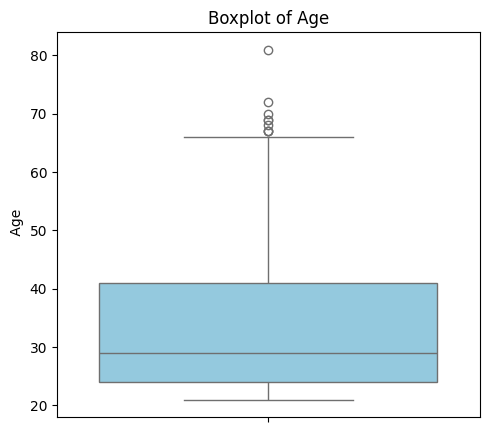

In [100]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,2)
sns.boxplot(df["Age"], color="skyblue")
plt.title("Boxplot of Age")
plt.ylabel(" Age")

# plt.tight_layout()


***Nhận Xét***

- Dữ liệu phân tán không đều lệch phải, tức phần lớn giá trị gần 0 xuất hiện thường xuyên hơn
- Càng về bên trái (giá trị lớn) tần suất càng giảm.
- Trung vị nẳm ở khoảng 30 cho thấy dữ liệu đa phần tập trung ở đây 
- Không nhiều giá trị ngoại lai

### Biến Phân Loại

C:\Users\LENOVO-PC\AppData\Local\Temp\ipykernel_16388\3517346257.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Outcome", data=df, palette="Set2")


Text(0, 0.5, 'Count')

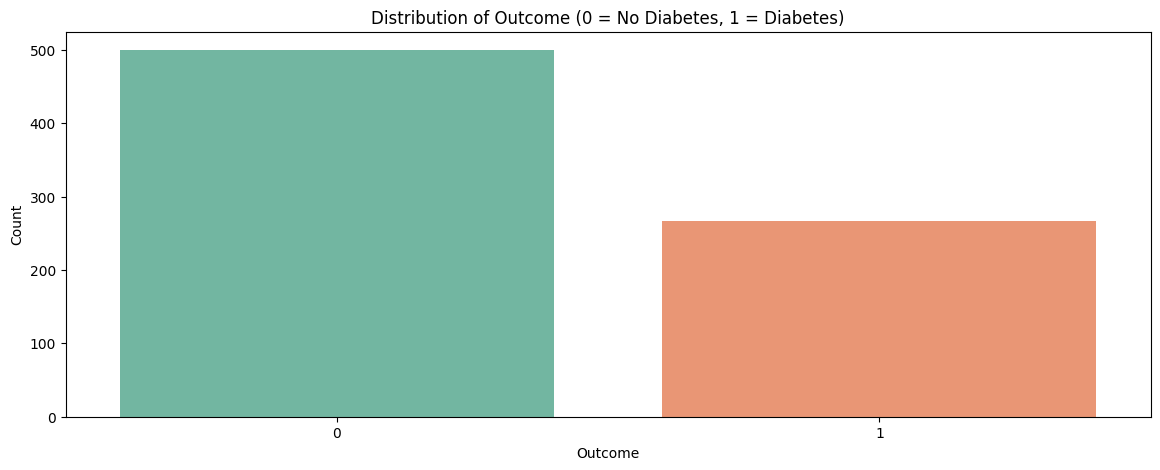

In [101]:
plt.figure(figsize= (14,5))
# plt.subplot(1,2,1)
sns.countplot(x="Outcome", data=df, palette="Set2")
plt.title("Distribution of Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.xlabel("Outcome")
plt.ylabel("Count")


## Phân tích hai biến

### Biến liên tục && Biến liên tục

#### Glucose && BMI

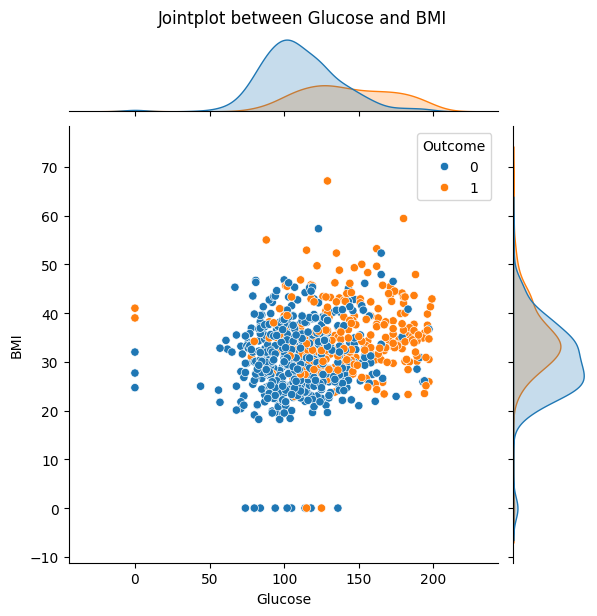

In [102]:

sns.jointplot(x="Glucose", y="BMI",  data=df, kind="scatter", hue="Outcome")
plt.suptitle("Jointplot between Glucose and BMI", y=1.02)
plt.show()

***Nhận Xét***
- Glucose là đặc trưng phân biệt Outcome mạnh nhất.

- BMI cũng có tác động, nhưng yếu hơn.

- Nhóm mắc bệnh thường tập trung ở vùng Glucose cao + BMI cao.

- Xuất hiện các giá trị bất thường (Glucose=0, BMI=0) cần xử lý.

#### Glucose && Age

Text(0.5, 1.02, 'Jointplot between Age vs Glucose (colored by Outcome)')

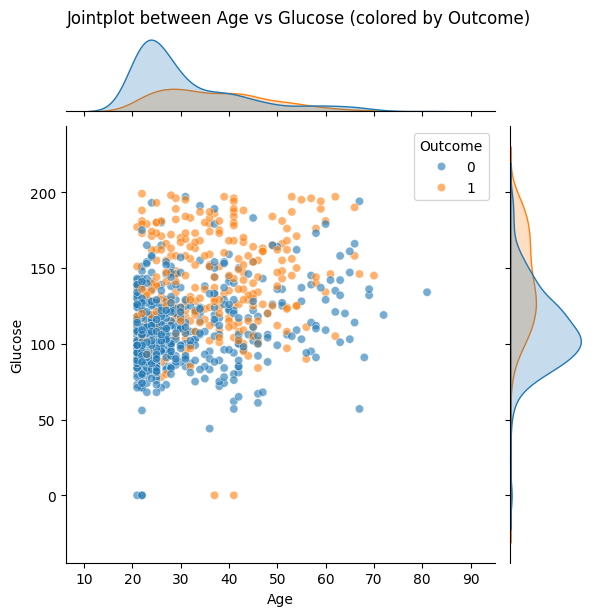

In [103]:
sns.jointplot(x="Age", y="Glucose", data=df, kind="scatter", hue="Outcome", alpha=0.6)

plt.suptitle("Jointplot between Age vs Glucose (colored by Outcome)", y=1.02)


***Nhận Xét***
- Glucose vẫn là yếu tố mạnh nhất để phân biệt Outcome.

- Tuổi (Age) bổ sung thông tin: người lớn tuổi có nguy cơ cao hơn.

- Kết hợp cả hai: người lớn tuổi + Glucose cao → nguy cơ tiểu đường đặc biệt cao.

- Có giá trị bất thường (Glucose=0) cần xử lý.

#### Glucose && Insulin

Text(0.5, 1.02, 'Jointplot between Glucose and Insulin')

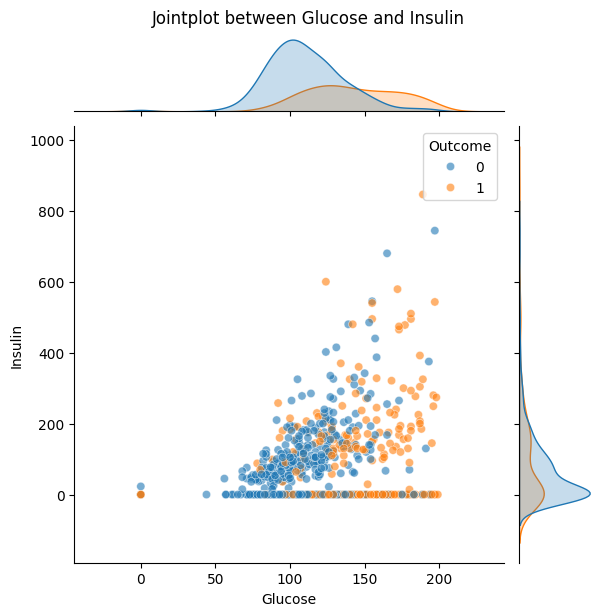

In [104]:
sns.jointplot(x= "Glucose", y="Insulin", data=df, kind="scatter", hue="Outcome", alpha=0.6)
plt.suptitle( "Jointplot between Glucose and Insulin", y = 1.02)

***Nhận xét***
- Glucose vẫn là đặc trưng phân biệt mạnh nhất.

- Insulin có quan hệ sinh học hợp lý với Glucose, nhưng dữ liệu có nhiều missing (0) và outlier → cần xử lý trước khi dùng mô hình.

- Nhóm Outcome=1 tập trung nhiều ở vùng Glucose cao + Insulin cao.

#### BMI && Age

Text(0.5, 1.02, 'Jointplot between BMI and Age')

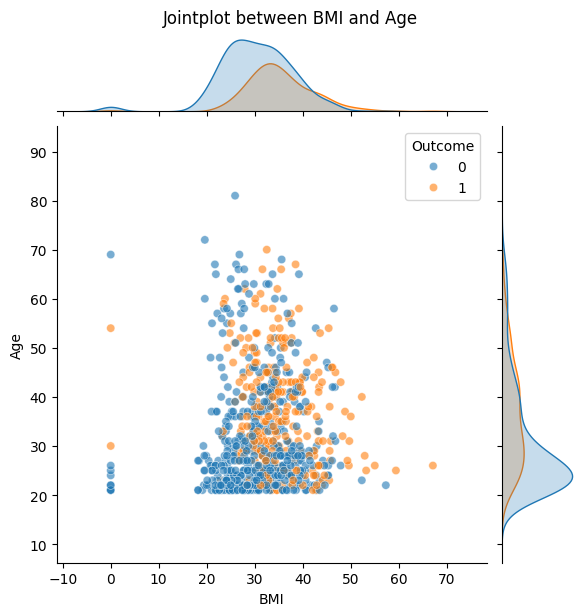

In [105]:
sns.jointplot(x="BMI", y="Age", data=df, kind="scatter", hue="Outcome", alpha=0.6)
plt.suptitle("Jointplot between BMI and Age", y= 1.02)

***Nhận Xét***
- BMI và Age đều liên quan đến nguy cơ tiểu đường..

- Người lớn tuổi và có BMI cao có nguy cơ cao hơn.

- Tuy nhiên, mức độ phân biệt Outcome giữa hai nhóm chưa thật rõ (có nhiều chồng lấn).

- Các giá trị bất thường (BMI=0, BMI>60).

#### BloodPressure && Age

Text(0.5, 1.02, 'Jointplot between BloodPressure and Age')

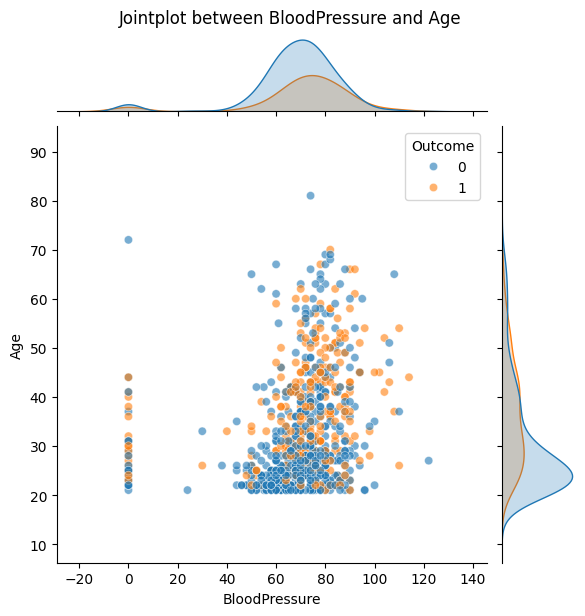

In [106]:
sns.jointplot(x="BloodPressure", y="Age", data=df, kind="scatter", hue="Outcome", alpha=0.6)
plt.suptitle("Jointplot between BloodPressure and Age", y= 1.02)

***Nhận Xét***
- Age vẫn là biến hữu ích (người lớn tuổi nguy cơ cao hơn).

- BloodPressure không có sự khác biệt rõ ràng giữa Outcome=0 và 1.

- Có nhiều giá trị bất thường (0 hoặc cực đoan) cần xử lý.

#### SkinThickness && BMI

Text(0.5, 1.02, 'Jointplot between SkinThickness and BMI')

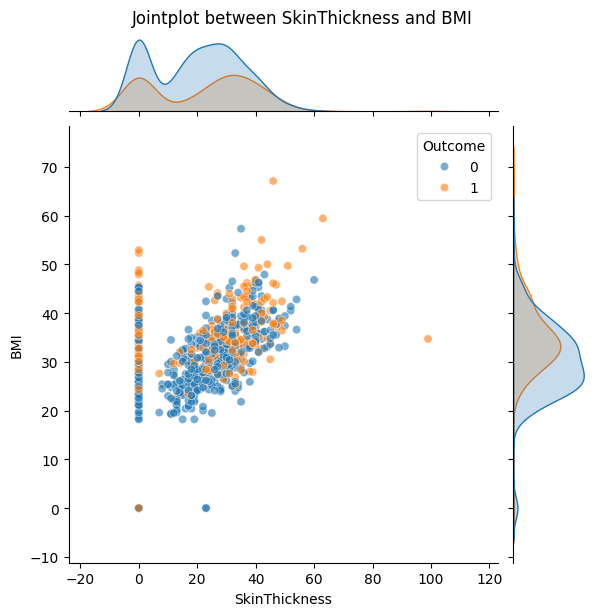

In [107]:
sns.jointplot(x="SkinThickness", y="BMI", data=df, kind="scatter", hue="Outcome", alpha=0.6)
plt.suptitle("Jointplot between SkinThickness and BMI", y= 1.02)

***Nhận Xét***
- SkinThickness và BMI có mối quan hệ mạnh với nhau suy ra không độc lập.

- Cả hai đặc trưng này đều liên quan đến béo phì, và gián tiếp đến nguy cơ tiểu đường.

- Cần xử lý missing (0) và outliers .

#### DPF && Glucose

Text(0.5, 1.02, 'Jointplot between DPF and Glucose')

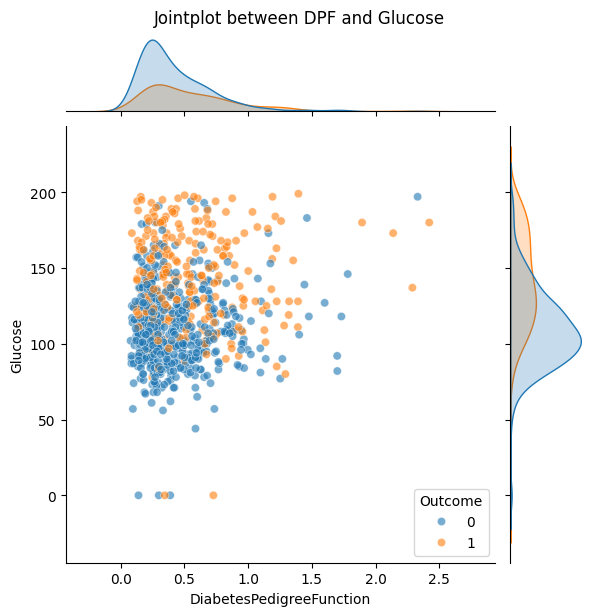

In [108]:
sns.jointplot(x="DiabetesPedigreeFunction", y="Glucose", data=df, kind="scatter", hue="Outcome", alpha=0.6)
plt.suptitle("Jointplot between DPF and Glucose", y= 1.02)

***Nhận Xét***
- Glucose vẫn là yếu tố chính để phân biệt Outcome.

- DPF mang ý nghĩa bổ sung, phản ánh yếu tố di truyền, dù mối quan hệ không mạnh bằng Glucose, BMI hay Age.

- Người có Glucose cao + DPF cao có nguy cơ đặc biệt cao → đây là sự kết hợp quan trọng trong dự đoán.

### Biến liên tục && Biến mục tiêu

#### Glucose && Outcome

C:\Users\LENOVO-PC\AppData\Local\Temp\ipykernel_16388\958182966.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y='Glucose', data=df, palette="Set2")


Text(0.5, 1.0, 'Boxplot: Glucose vs Outcome')

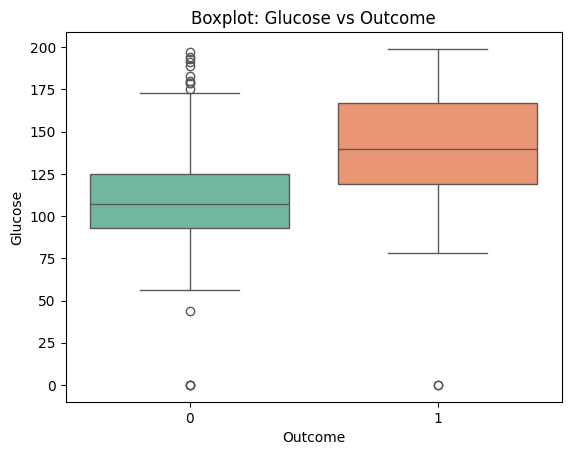

In [109]:
sns.boxplot(x='Outcome', y='Glucose', data=df, palette="Set2")
plt.title("Boxplot: Glucose vs Outcome")

***Nhận Xét***
- Glucose cao hơn rõ rệt ở nhóm mắc tiểu đường (Outcome=1).

- Có nhiều giá trị bất thường (Glucose=0, Glucose rất cao) cần xử lý.

#### BloodPressure && Outcome

C:\Users\LENOVO-PC\AppData\Local\Temp\ipykernel_16388\3317746040.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y='BloodPressure', data=df, palette="Set2")


Text(0.5, 1.0, 'Boxplot: BloodPressure vs Outcome')

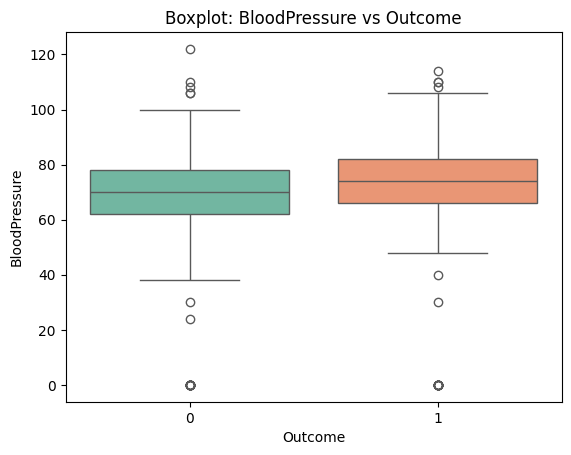

In [110]:
sns.boxplot(x='Outcome', y='BloodPressure', data=df, palette="Set2")
plt.title("Boxplot: BloodPressure vs Outcome")

***Nhận Xét***

- BloodPressure có chút khác biệt (người mắc bệnh thường cao hơn), nhưng không rõ rệt.

- Có nhiều giá trị bất hợp lý (0) và ngoại lệ cần xử lý.

- Biến này không quan trọng bằng Glucose, BMI, Age trong mô hình dự đoán.

#### Insulin && Outcome

C:\Users\LENOVO-PC\AppData\Local\Temp\ipykernel_16388\677891032.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x= "Outcome", y= "Insulin", data=df, palette="Set2")


Text(0.5, 1.0, 'Boxplot: Insulin vs Outcome')

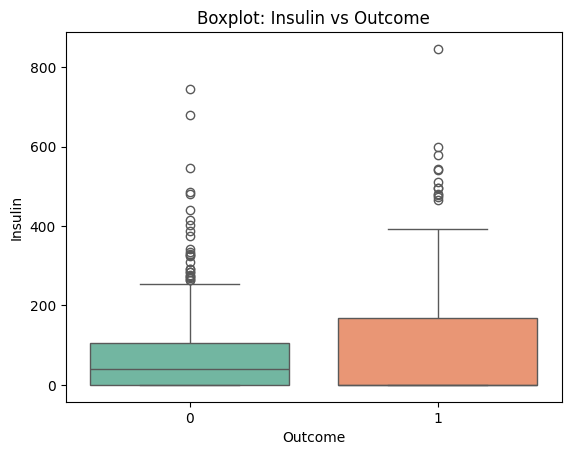

In [111]:
sns.boxplot(x= "Outcome", y= "Insulin", data=df, palette="Set2")
plt.title("Boxplot: Insulin vs Outcome")

***Nhận Xét***
- Insulin có xu hướng cao hơn ở nhóm mắc bệnh.

- Dữ liệu chứa nhiều giá trị bất thường (0 và cực lớn) cần xử lý.

- Nếu làm sạch dữ liệu (imputation cho 0, cắt outliers), biến Insulin có thể đóng vai trò quan trọng hơn trong mô hình dự đoán.

#### BMI && Outcome

C:\Users\LENOVO-PC\AppData\Local\Temp\ipykernel_16388\287121621.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x= "Outcome", y= "BMI", data=df, palette="Set2")


Text(0.5, 1.0, 'Boxplot: BMI vs Outcome')

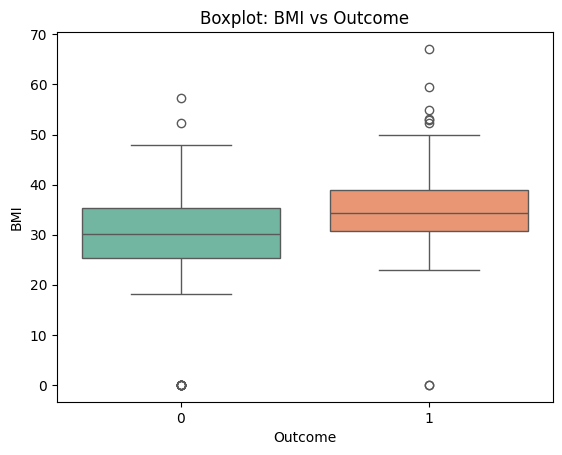

In [112]:
sns.boxplot(x= "Outcome", y= "BMI", data=df, palette="Set2")
plt.title("Boxplot: BMI vs Outcome")

***Nhận Xét***
- Người bị tiểu đường thường có chỉ số BMI cao hơn đáng kể so với người không bị. 

- Dữ liệu có một số giá trị bất thường (BMI = 0) cần xử lý.

#### DiabetesPedigreeFunction(DPF) && Outcome

C:\Users\LENOVO-PC\AppData\Local\Temp\ipykernel_16388\3324925257.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x= "Outcome", y= "DiabetesPedigreeFunction", data=df, palette="Set2")


Text(0.5, 1.0, 'Boxplot: DPF vs Outcome')

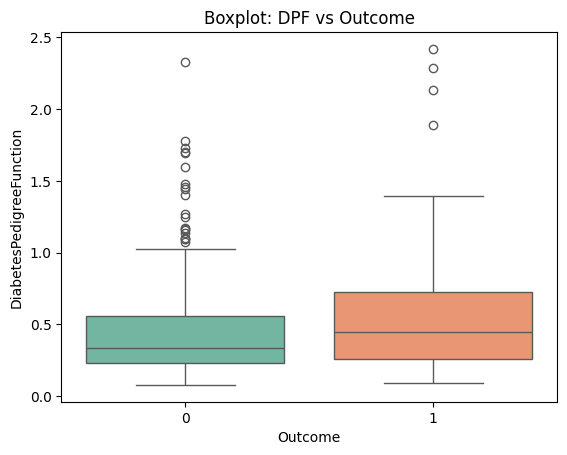

In [113]:
sns.boxplot(x= "Outcome", y= "DiabetesPedigreeFunction", data=df, palette="Set2")
plt.title("Boxplot: DPF vs Outcome")

***Nhận Xét***
- Người mắc tiểu đường thường có chỉ số DPF cao hơn một chút, phản ánh yếu tố di truyền gia đình. 
- Cả hai nhóm đều có nhiều ngoại lệ cao.

#### Age && Outcome

C:\Users\LENOVO-PC\AppData\Local\Temp\ipykernel_16388\1585589837.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x= "Outcome", y= "Age", data=df, palette="Set2")


Text(0.5, 1.0, 'Boxplot: Age vs Outcome')

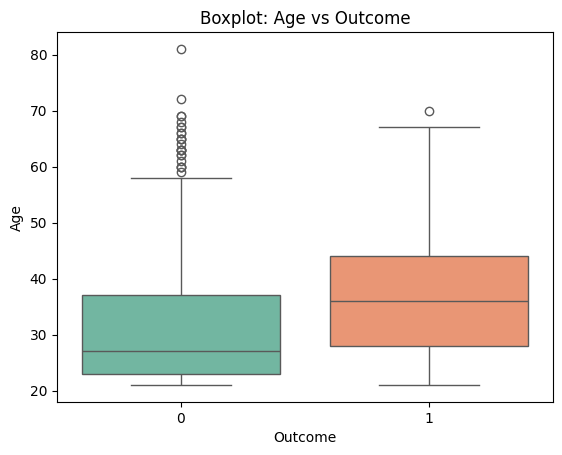

In [114]:
sns.boxplot(x= "Outcome", y= "Age", data=df, palette="Set2")
plt.title("Boxplot: Age vs Outcome")

***Nhận Xét***

- Người mắc tiểu đường thường lớn tuổi hơn rõ rệt so với người không mắc.

- Cả hai nhóm đều có một số giá trị tuổi cao bất thường (trên 65–80), nhưng nhóm không tiểu đường có nhiều ngoại lệ cao hơn.


### Ma trận tương quan

In [115]:
corr = df.corr()
corr

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.128846,0.141197,-0.082495,-0.072999,0.017518,-0.033927,0.544018,0.221087
Glucose,0.128846,1.000000,0.152498,0.056381,0.332383,0.220955,0.136903,0.262408,0.465856
BloodPressure,0.141197,0.152498,1.000000,0.207308,0.089098,0.281777,0.041180,0.239571,0.064882
SkinThickness,-0.082495,0.056381,0.207308,1.000000,0.437974,0.392553,0.183498,-0.115873,0.073265
Insulin,-0.072999,0.332383,0.089098,0.437974,1.000000,0.198111,0.185579,-0.040942,0.131984
BMI,0.017518,0.220955,0.281777,0.392553,0.198111,1.000000,0.140546,0.035911,0.292695
DiabetesPedigreeFunction,-0.033927,0.136903,0.041180,0.183498,0.185579,0.140546,1.000000,0.032738,0.173245
Age,0.544018,0.262408,0.239571,-0.115873,-0.040942,0.035911,0.032738,1.000000,0.236417
Outcome,0.221087,0.465856,0.064882,0.073265,0.131984,0.292695,0.173245,0.236417,1.000000


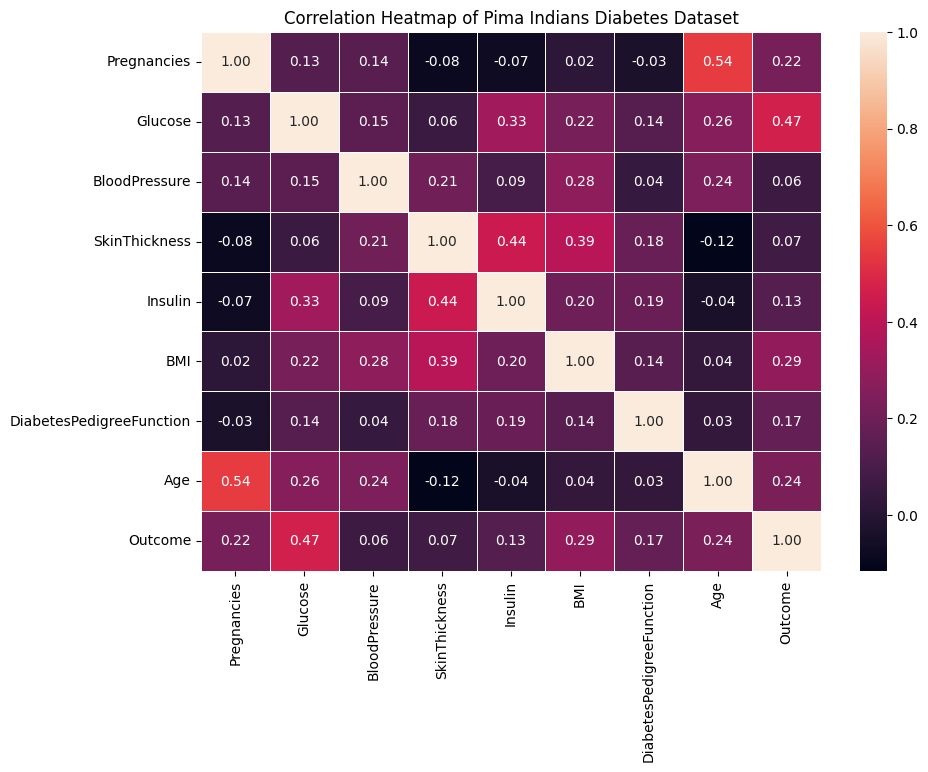

In [116]:

plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Pima Indians Diabetes Dataset")
plt.show()

In [117]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
# Lấy các đặc trưng (không lấy Outcome)
X = df.drop("Outcome", axis=1)

# Thêm hằng số cho mô hình hồi quy
X_const = add_constant(X)

# Tính VIF cho từng đặc trưng
vif_data = pd.DataFrame()
vif_data["Feature"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]

print(vif_data)

                    Feature        VIF
0                     const  35.033583
1               Pregnancies   1.430170
2                   Glucose   1.299281
3             BloodPressure   1.182160
4             SkinThickness   1.511085
5                   Insulin   1.430932
6                       BMI   1.297609
7  DiabetesPedigreeFunction   1.066907
8                       Age   1.587250


***Nhận Xét***
- Glucose và Outcome có mối tương quan dương khá cao (0,47). So với cái biến còn lại thì Glucose là biến có mối tương quan mạnh nhất đối với Outcome. → đường huyết có ảnh hưởng rõ rệt đến việc mắc tiểu đường
- BMI so với Glucose có mối tương quan dương 0.29 → mức ảnh hưởng vừa
- Bên cạnh đó còn có các biến Age và Pregnancies cũng có tương quan nhưng khá thấp (0.24, 0.22). Có ảnh hưởng đến Outcome nhưn gkh đáng kể
- Ngoài ra Age có tương quan 0.54 với Pregnancies (rất cao). Phụ nữ lớn tuổi thường có số lần mang thai cao hơn. 
    + Đây là quan hệ logic, nhưng cũng cho thấy Pregnancies và Age không độc lập → có thể gây đa cộng tuyến
    + Nhưng VIF < 2 nên không hề có đa cộng tuyến đáng kể.
- SkinThickness && Insulin (0.44) và SkinThickness && BMI (0.39) → người có BMI cao thường có lớp mỡ dưới da dày hơn, và có liên quan đến mức Insulin.
- Insulin && Glucose (0.33) → hợp lý, vì insulin điều hòa đường huyết.


## Phân tích đa biến

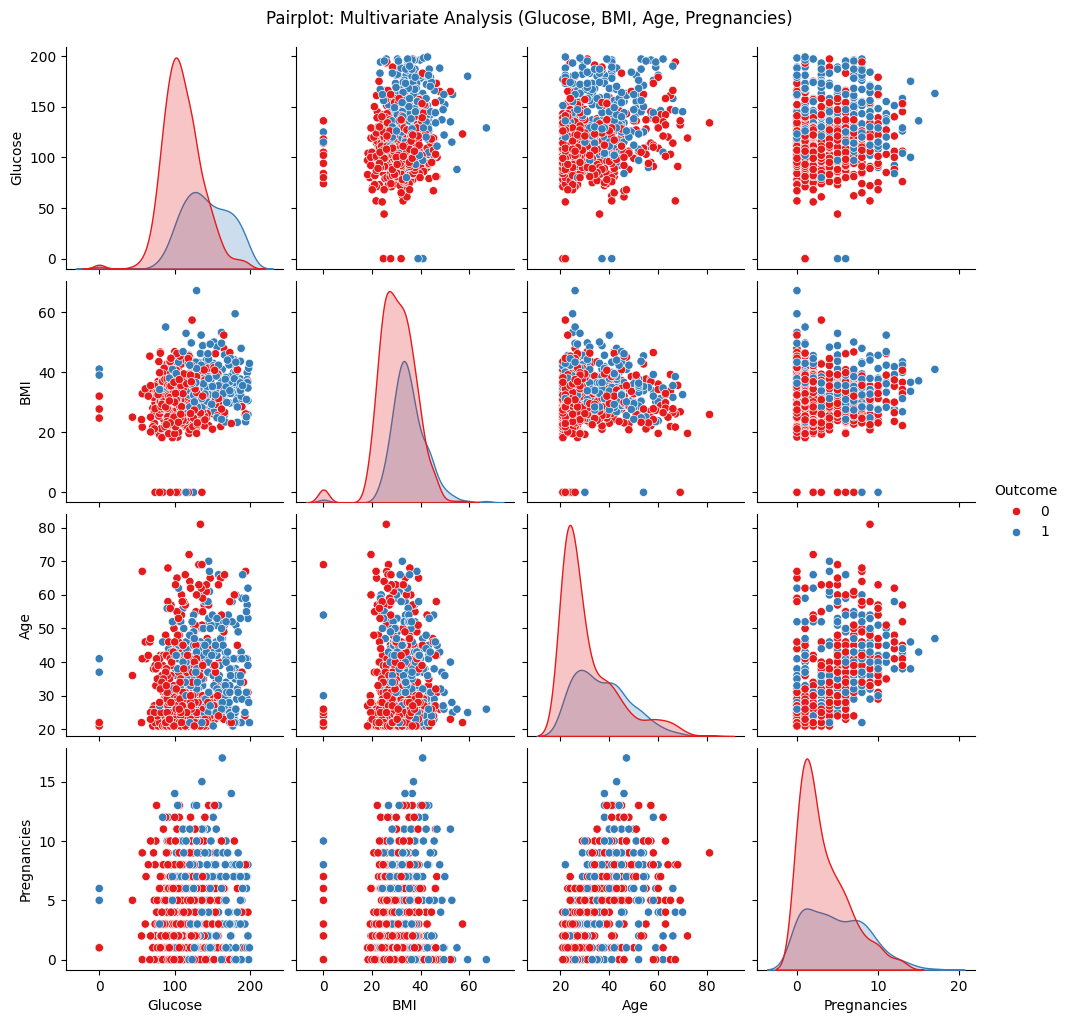

In [118]:
# Chọn 4 biến quan trọng
features = ["Glucose", "BMI", "Age", "Pregnancies"]

# Vẽ pairplot
sns.pairplot(df[features + ["Outcome"]], hue="Outcome", diag_kind="kde", palette="Set1")
plt.suptitle("Pairplot: Multivariate Analysis (Glucose, BMI, Age, Pregnancies)", y=1.02)
plt.show()

***Nhận Xét***
- Đường chéo: KDE plot
    + Glucose của nhóm Outcome=1 dịch sang phải rõ rệt
- Glucose vs BMI: nhóm mắc bệnh tập trung ở Glucose cao + BMI cao.
- Age vs Pregnancies: Outcome=1 xuất hiện nhiều hơn ở tuổi cao.
- BMI vs Age: BMI cao kết hợp với tuổi cao → nhiều khả năng mắc bệnh.

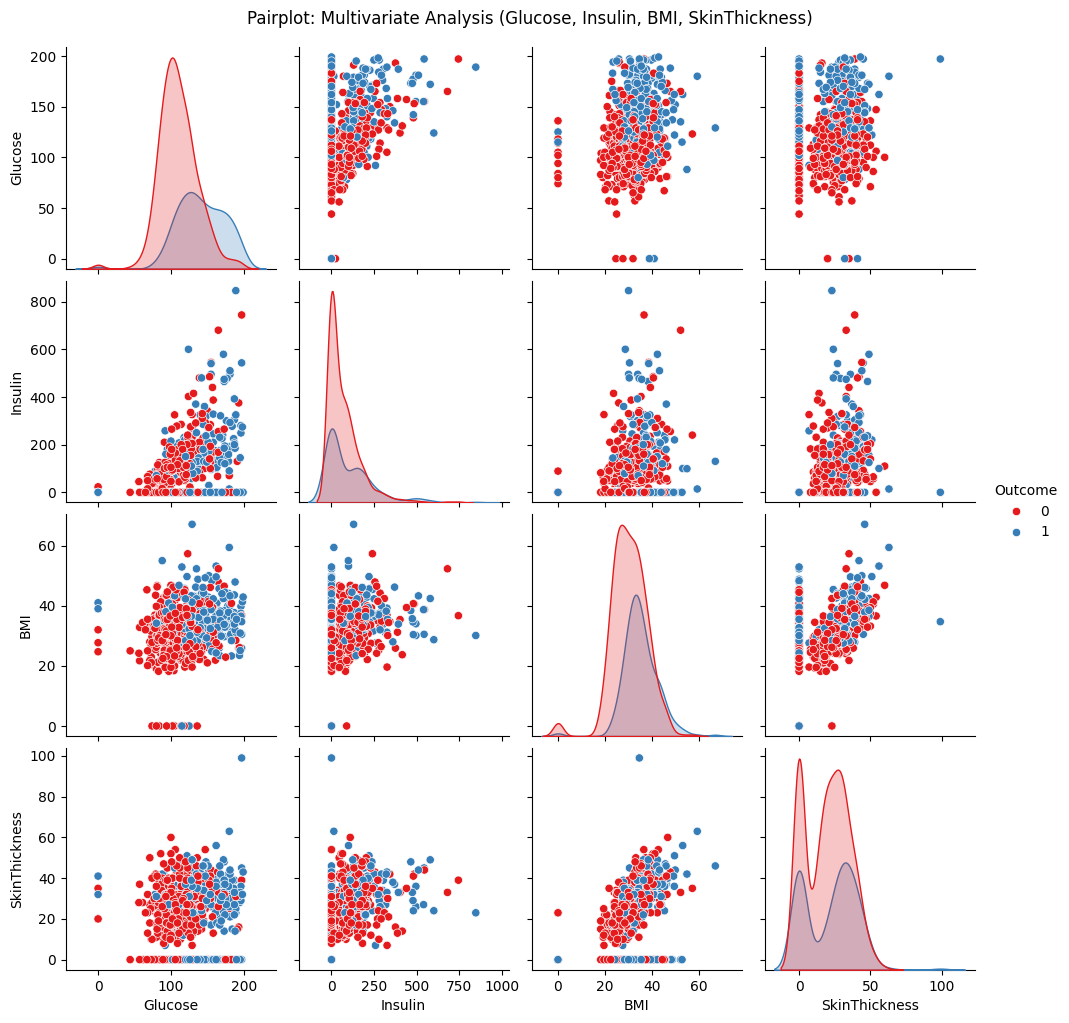

In [119]:
# Nhóm đặc trưng chuyển hóa
features_metabolic = ["Glucose", "Insulin", "BMI", "SkinThickness"]

# Vẽ pairplot
sns.pairplot(df[features_metabolic + ["Outcome"]], hue="Outcome", diag_kind="kde", palette="Set1")
plt.suptitle("Pairplot: Multivariate Analysis (Glucose, Insulin, BMI, SkinThickness)", y=1.02)
plt.show()

***Nhận Xét***
- Glucose vs Insulin → Outcome=1 tập trung nhiều ở Glucose cao, Insulin phân tán rộng.
- BMI vs SkinThickness → Outcome=1 thường ở BMI và SkinThickness cao hơn.
- KDE plot trên đường chéo
    + Glucose (Outcome=1) lệch phải rõ rệt (cao hơn).
    + Insulin & SkinThickness ít khác biệt hơn, nhưng phân bố có xu hướng rộng hơn ở Outcome=1.



# **DATA PROCESSING - TIỀN XỬ LÝ DỮ LIỆU**

## Data

In [120]:
df = pd.read_csv('../../data/pima-indians-diabetes.csv')
df.columns = [
    "Pregnancies","Glucose","BloodPressure","SkinThickness",
    "Insulin","BMI","DiabetesPedigreeFunction","Age","Outcome"
]

In [121]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,85,66,29,0,26.6,0.351,31,0
1,8,183,64,0,0,23.3,0.672,32,1
2,1,89,66,23,94,28.1,0.167,21,0
3,0,137,40,35,168,43.1,2.288,33,1
4,5,116,74,0,0,25.6,0.201,30,0


In [122]:
# 2. Xác định các cột có giá trị 0 bất hợp lý -> coi là missing
cols_with_missing = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]

for col in cols_with_missing:
    df[col] = df[col].replace(0, np.nan)

print("Số lượng missing values sau khi thay 0 -> NaN:")
print(df.isna().sum())

Số lượng missing values sau khi thay 0 -> NaN:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     373
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [123]:
# 3. Xử lý missing bằng median imputation
imputer = SimpleImputer(strategy="median")
df[cols_with_missing] = imputer.fit_transform(df[cols_with_missing])

In [124]:
# 4. Chia dữ liệu thành X, y
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# 5. Chia train/test (80/20, stratify theo y để giữ tỷ lệ Outcome)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. Chuẩn hóa dữ liệu (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [125]:
print("\nKích thước dữ liệu:")
print("Train:", X_train_scaled.shape, "Test:", X_test_scaled.shape)


Kích thước dữ liệu:
Train: (613, 8) Test: (154, 8)


# **MODEL-TRAINING**

In [126]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

## Logistic Regression

In [127]:
# 1. Khởi tạo mô hình Logistic Regression
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)

# 2. Huấn luyện mô hình
log_reg.fit(X_train_scaled, y_train)





,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [128]:
# 3. Dự đoán trên test set
y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]  # xác suất thuộc lớp 1

In [129]:
# 4. Đánh giá mô hình
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1-score:", f1_score(y_test, y_pred_lr))
print("ROC AUC:", roc_auc_score(y_test, y_proba_lr))

print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))


Accuracy: 0.7077922077922078
Precision: 0.576271186440678
Recall: 0.6296296296296297
F1-score: 0.6017699115044248
ROC AUC: 0.7881481481481482

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.75      0.77       100
           1       0.58      0.63      0.60        54

    accuracy                           0.71       154
   macro avg       0.68      0.69      0.69       154
weighted avg       0.71      0.71      0.71       154



## Random Forest

In [130]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
rf.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [131]:
y_pred_rf = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_proba_rf))

Accuracy: 0.7012987012987013
ROC AUC: 0.7925925925925925


## Stacking

In [132]:

# 1. Các mô hình base learners
base_learners = [
    ("lr", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
    ("rf", RandomForestClassifier(n_estimators=100, random_state=42)),
    ("gb", GradientBoostingClassifier(random_state=42)),
    ("svm", SVC(probability=True, random_state=42))
]

# 2. Meta model (stacking layer cuối cùng)
meta_model = LogisticRegression(max_iter=1000, random_state=42)

# 3. Xây dựng Stacking Classifier
stacking_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1
)

# 4. Huấn luyện
stacking_clf.fit(X_train_scaled, y_train)




,estimators,"[('lr', ...), ('rf', ...), ...]"
,final_estimator,LogisticRegre...ndom_state=42)
,cv,5
,stack_method,'auto'
,n_jobs,-1
,passthrough,False
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [133]:

# 5. Dự đoán
y_pred_stack = stacking_clf.predict(X_test_scaled)
y_proba_stack = stacking_clf.predict_proba(X_test_scaled)[:, 1]

In [134]:
# 6. Đánh giá
print("Accuracy:", accuracy_score(y_test, y_pred_stack))
print("ROC AUC:", roc_auc_score(y_test, y_proba_stack))

Accuracy: 0.7077922077922078
ROC AUC: 0.7925925925925925


# **EVALUATE**

In [135]:
def evaluate_model(name, y_true, y_pred, y_proba):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
        "ROC AUC": roc_auc_score(y_true, y_proba)
    }

# 5. Tổng hợp kết quả
results = []
results.append(evaluate_model("Logistic Regression", y_test, y_pred_lr, y_proba_lr))
results.append(evaluate_model("Random Forest", y_test, y_pred_rf, y_proba_rf))
results.append(evaluate_model("Stacking", y_test, y_pred_stack, y_proba_stack))

df_results = pd.DataFrame(results)
print(df_results)

                 Model  Accuracy  Precision    Recall  F1-score   ROC AUC
0  Logistic Regression  0.707792   0.576271  0.629630  0.601770  0.788148
1        Random Forest  0.701299   0.586957  0.500000  0.540000  0.792593
2             Stacking  0.707792   0.595745  0.518519  0.554455  0.792593


Text(0.5, 1.0, 'Confusion Matrix - Stacking')

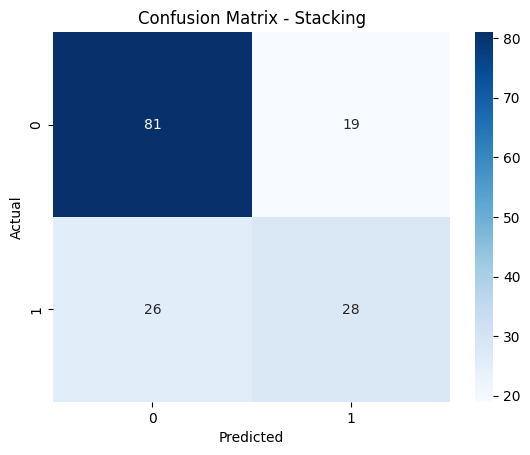

In [136]:
cm = confusion_matrix(y_test, y_pred_stack)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Stacking")

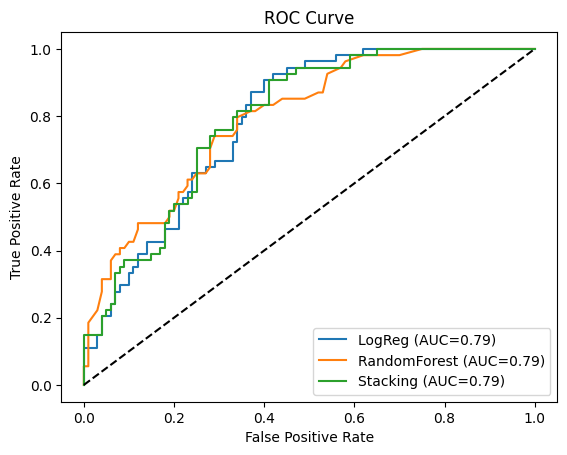

In [137]:

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_stack, tpr_stack, _ = roc_curve(y_test, y_proba_stack)

plt.plot(fpr_lr, tpr_lr, label="LogReg (AUC=%.2f)" % auc(fpr_lr, tpr_lr))
plt.plot(fpr_rf, tpr_rf, label="RandomForest (AUC=%.2f)" % auc(fpr_rf, tpr_rf))
plt.plot(fpr_stack, tpr_stack, label="Stacking (AUC=%.2f)" % auc(fpr_stack, tpr_stack))
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

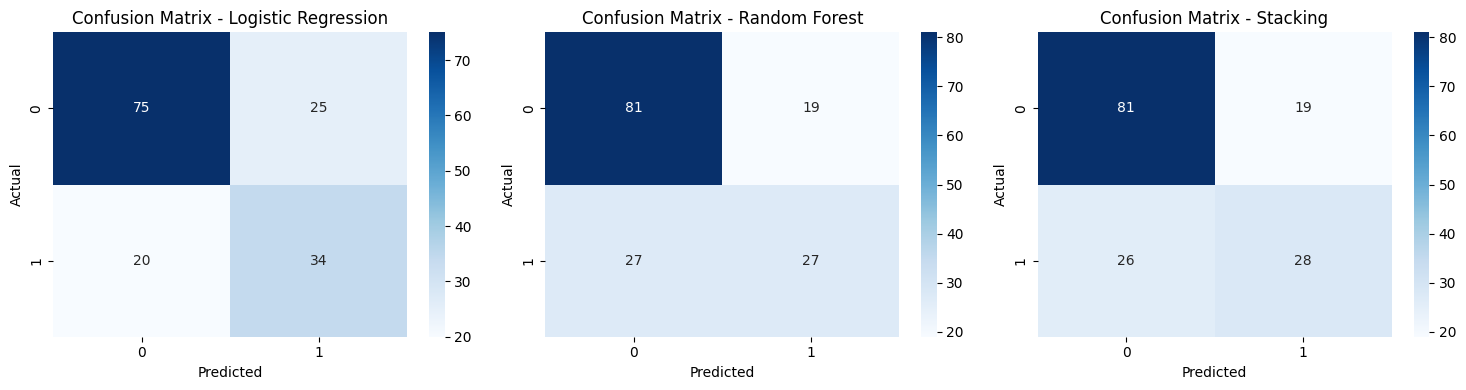

In [138]:
models = {
    "Logistic Regression": (y_pred_lr, y_proba_lr),
    "Random Forest": (y_pred_rf, y_proba_rf),
    "Stacking": (y_pred_stack, y_proba_stack)
}

# 1. Confusion Matrix cho từng mô hình
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (name, (y_pred, y_proba)) in enumerate(models.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                xticklabels=[0,1], yticklabels=[0,1], ax=axes[i])
    axes[i].set_title(f"Confusion Matrix - {name}")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.tight_layout()